# Análisis de Churn en Netflix mediante Enriquecimiento con APIs Externas

La retención de clientes representa uno de los principales desafíos para las plataformas de streaming por suscripción.
Comprender las razones detrás de la cancelación del servicio requiere analizar no solo el comportamiento interno
de los usuarios, sino también el contexto externo relacionado con la oferta y popularidad del contenido.

En este proyecto se analiza un dataset de deserción (churn) de Netflix que contiene información demográfica, de consumo
y de suscripción de los clientes. Dicho dataset es enriquecido mediante la integración de la API de Wikidata y la API de Google Trends, incorporando métricas externas sobre disponibilidad,
calidad y popularidad de los géneros preferidos por los usuarios.

El objetivo es evaluar cómo la interacción entre métricas internas de uso y variables externas de contenido
influye en la probabilidad de churn. Este análisis está orientado equipos de producto, marketing y CRM
interesados en comprender el impacto del valor del contenido y las tendencias de consumo en la retención
de clientes.


## Preguntas de investigación e hipótesis

A partir del análisis de churn de clientes de Netflix y del enriquecimiento del dataset
mediante APIs externas (Wikidata y Google Trends), se plantean las siguientes preguntas
de investigación y sus hipótesis asociadas:

**Preguntas**
- ¿Existe relación entre la oferta de contenido disponible del género favorito de los usuarios y la probabilidad de abandono de la plataforma?
- ¿La volatilidad del interés externo por un género, medida a partir de datos de Google Trends, se asocia con mayores niveles de abandono?
- ¿Se observan diferencias en el nivel de uso de la plataforma entre usuarios que abandonan y usuarios que permanecen activos?
- ¿La tendencia temporal del interés por un género influye en el nivel de engagement previo al abandono?

**Hipótesis**
- Los usuarios cuyos géneros favoritos cuentan con una menor cantidad de títulos disponibles presentan una mayor probabilidad de abandono.
- Los géneros que exhiben una mayor volatilidad en el interés de búsqueda presentan mayores tasas de abandono entre sus usuarios.
- Los usuarios que abandonan la plataforma muestran, en promedio, menores niveles de uso que aquellos que permanecen activos.
- Los géneros con una tendencia decreciente en el interés de búsqueda se asocian con una reducción del engagement previo al abandono.


## 1. Carga del dataset
Se carga el dataset `netflix_customer_churn.csv` y se revisan columnas, tipos y valores faltantes.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('netflix_customer_churn.csv')
df.head()

# Estilo base
plt.style.use("dark_background")

# Colores Netflix
NETFLIX_RED = "#E50914"
NETFLIX_GRAY = "#B3B3B3"
NETFLIX_DARK_GRAY = "#221F1F"
NETFLIX_WHITE = "#FFFFFF"
NETFLIX_BLACK = "#000000"

# Paleta por defecto
sns.set_palette([NETFLIX_GRAY, NETFLIX_RED])

# Configuración global
plt.rcParams.update({
    "figure.facecolor": NETFLIX_BLACK,
    "axes.facecolor": NETFLIX_BLACK,
    "axes.edgecolor": NETFLIX_WHITE,
    "axes.labelcolor": NETFLIX_WHITE,
    "xtick.color": NETFLIX_WHITE,
    "ytick.color": NETFLIX_WHITE,
    "text.color": NETFLIX_WHITE,
    "grid.color": NETFLIX_DARK_GRAY,
    "axes.titleweight": "bold",
    "axes.titlesize": 14
})



## 2. Limpieza de datos

El dataset no presenta valores faltantes ni inconsistencias estructurales.
La limpieza se enfocó en asegurar consistencia de tipos y normalización básica de variables categóricas, preparando los datos para el análisis exploratorio y el enriquecimiento externo.


In [5]:
df_clean = df.copy()

# Con esto controlo los duplicados y los elimino
print("Duplicados antes:", df_clean.duplicated().sum())

df_clean = df_clean.drop_duplicates()

print("Duplicados después:", df_clean.duplicated().sum())

# Convertimos las variables numéricas
numeric_cols = [
    "age",
    "watch_hours",
    "monthly_fee",
    "avg_watch_time_per_day",
    "last_login_days",
    "number_of_profiles",
    "churned"
]

for col in numeric_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

# Limpio las variab categóricas
categorical_cols = [
    "gender",
    "subscription_type",
    "region",
    "device",
    "payment_method",
    "favorite_genre"
]

for col in categorical_cols:
    df_clean[col] = (
        df_clean[col]
        .astype(str)
        .str.strip()
        .str.title()
    )

# Chequeo valores nulos
print("\nValores nulos por columna:")
print(df_clean.isnull().sum())

# Info final del dataset limpio
print("\nInformación general del dataset limpio:")
df_clean.info()

print("\nDimensiones finales:", df_clean.shape)

Duplicados antes: 0
Duplicados después: 0

Valores nulos por columna:
customer_id               0
age                       0
gender                    0
subscription_type         0
watch_hours               0
last_login_days           0
region                    0
device                    0
monthly_fee               0
churned                   0
payment_method            0
number_of_profiles        0
avg_watch_time_per_day    0
favorite_genre            0
dtype: int64

Información general del dataset limpio:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             5000 non-null   object 
 1   age                     5000 non-null   int64  
 2   gender                  5000 non-null   object 
 3   subscription_type       5000 non-null   object 
 4   watch_hours             5000 non-null   float64
 5   l

## 3. Enriquecimiento con Wikidata

Se incorporó información externa desde Wikidata para contextualizar la oferta de contenido disponible por género.

A través de una consulta SPARQL se obtuvo la **cantidad total de títulos asociados a cada género**, lo que permitió construir una medida de oferta relativa del catálogo.

Esta variable (`wikidata_total_titles`) se utiliza posteriormente para:

- Calcular el percentil de oferta por género.
- Construir el Content Saturation Index (Índice de Saturación de Contenido).

El objetivo no es describir características individuales de las películas, sino aproximar el tamaño estructural del catálogo disponible para cada categoría.


In [6]:
from SPARQLWrapper import SPARQLWrapper, JSON
import time

# Conexión a Wikidata
sparql = SPARQLWrapper("https://query.wikidata.org/sparql")
sparql.setReturnFormat(JSON)
sparql.addCustomHttpHeader(
    "User-Agent",
    "Netflix-Churn-Academic-Project/1.0"
)

# Géneros del dataset original
genres = df_clean["favorite_genre"].value_counts().index.tolist()

# Mapeo a Wikidata
wikidata_genres = {
    "Drama": "Q130232",
    "Comedy": "Q157443",
    "Action": "Q319221",
    "Romance": "Q188473",
    "Horror": "Q200092",
    "Sci-Fi": "Q471839",
    "Documentary": "Q93204"
}

results = []

for genre in genres:
    if genre not in wikidata_genres:
        continue

    qid = wikidata_genres[genre]

    query = f"""
    SELECT (COUNT(?film) AS ?filmCount)
    WHERE {{
      ?film wdt:P31 wd:Q11424.
      ?film wdt:P136 wd:{qid}.
    }}
    """

    sparql.setQuery(query)

    try:
        response = sparql.query().convert()
        count = int(
            response["results"]["bindings"][0]["filmCount"]["value"]
        )

        results.append({
            "favorite_genre": genre,
            "wikidata_total_titles": count
        })

    except Exception:
        results.append({
            "favorite_genre": genre,
            "wikidata_total_titles": None
        })

    time.sleep(1)

# DataFrame externo
wikidata_df = pd.DataFrame(results)

# Merge con dataset limpio
df_enriched = df_clean.merge(
    wikidata_df,
    on="favorite_genre",
    how="left"
)

df_enriched.head()


,customer_id,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre,wikidata_total_titles
0,a9b75100-82a8-427a-a208-72f24052884a,51,Other,Basic,14.73,29,Africa,Tv,8.99,1,Gift Card,1,0.49,Action,5621
1,49a5dfd9-7e69-4022-a6ad-0a1b9767fb5b,47,Other,Standard,0.70,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi,4276
2,4d71f6ce-fca9-4ff7-8afa-197ac24de14b,27,Female,Standard,16.32,10,Asia,Tv,13.99,0,Crypto,2,1.48,Drama,74427
3,d3c72c38-631b-4f9e-8a0e-de103cad1a7d,53,Other,Premium,4.51,12,Oceania,Tv,17.99,1,Crypto,2,0.35,Horror,9440
4,4e265c34-103a-4dbb-9553-76c9aa47e946,56,Other,Standard,1.89,13,Africa,Mobile,13.99,1,Crypto,2,0.13,Action,5621


## 4. Enriquecimiento externo con Google Trends
Se utiliza la API pública `pytrends` para medir popularidad y volatilidad de los géneros.

### Métricas analizadas

- **Volatilidad:** Indica la variabilidad o fluctuación en la popularidad del género a lo largo del tiempo. Un valor alto de volatilidad significa que la popularidad del género cambia mucho, mientras que un valor bajo indica estabilidad.
  
- **Pendiente de tendencia:** Representa la dirección general de la popularidad en el tiempo. Valores positivos indican que la popularidad del género está aumentando, mientras que valores negativos reflejan una disminución.


In [7]:
from pytrends.request import TrendReq
from scipy.stats import linregress

# Géneros a consultar
genres = ['Drama', 'Comedy', 'Action', 'Romance', 'Horror', 'Sci-Fi', 'Documentary']

# Función para dividir lista en chunks de tamaño n
def chunks(lst, n):
    for i in range(0, len(lst), n):
        yield lst[i:i + n]

# Conexión pytrends
pytrends = TrendReq(hl='es-ES', tz=360)

timeframe = '2020-01-01 2023-12-31' #Tuve que limitarlo porque sino el import fallaba, revisar para entrega final

dfs = []

# Consultar en grupos de máximo 5 géneros
for group in chunks(genres, 5):
    pytrends.build_payload(group, timeframe=timeframe)
    data = pytrends.interest_over_time()
    if 'isPartial' in data.columns:
        data = data.drop(columns=['isPartial'])
    dfs.append(data)

# Unir todos los resultados por fecha
data_all = pd.concat(dfs, axis=1)

# Calcular volatilidad y tendencia para cada género
volatility = {}
trend_slope = {}

for genre in genres:
    series = data_all[genre].dropna()
    volatility[genre] = np.std(series)
    x = np.arange(len(series))
    slope, _, _, _, _ = linregress(x, series)
    trend_slope[genre] = slope

print("Volatilidad por género:")
print(volatility)

print("\nPendiente de tendencia por género:")
print(trend_slope)

Volatilidad por género:
{'Drama': np.float64(4.044763698744935), 'Comedy': np.float64(3.7784446523575954), 'Action': np.float64(6.134057928212503), 'Romance': np.float64(1.8207733026110458), 'Horror': np.float64(5.445878842930871), 'Sci-Fi': np.float64(0.46229732949875235), 'Documentary': np.float64(7.461641895269608)}

Pendiente de tendencia por género:
{'Drama': np.float64(-0.032993945440939705), 'Comedy': np.float64(-0.03269137946114748), 'Action': np.float64(0.05479359752245759), 'Romance': np.float64(0.008228887600301927), 'Horror': np.float64(0.027346263115781696), 'Sci-Fi': np.float64(0.0025714868817887024), 'Documentary': np.float64(0.004295529863003049)}


### Resultados obtenidos

### Volatilidad del Consumo por Género

La volatilidad mide la variabilidad en las horas de visualización dentro de cada género.  
Valores más altos indican mayor fluctuación en el comportamiento de consumo.

| Género        | Volatilidad |
|--------------|------------|
| Documentary  | 7.46 |
| Action       | 6.13 |
| Horror       | 5.45 |
| Drama        | 4.04 |
| Comedy       | 3.78 |
| Romance      | 1.82 |
| Sci-Fi       | 0.46 |

**Interpretación:**
- *Documentary* y *Action* presentan el comportamiento más inestable.
- *Sci-Fi* muestra el consumo más estable.
- Géneros con alta volatilidad podrían estar asociados a usuarios con patrones menos consistentes.

---

### Pendiente de Tendencia por Género

La pendiente indica la dirección del comportamiento de consumo:
- Valores positivos → tendencia creciente.
- Valores negativos → tendencia decreciente.

| Género        | Pendiente |
|--------------|-----------|
| Action       | +0.055 |
| Horror       | +0.027 |
| Romance      | +0.008 |
| Documentary  | +0.004 |
| Sci-Fi       | +0.003 |
| Comedy       | -0.033 |
| Drama        | -0.033 |

**Interpretación:**
- *Action* y *Horror* muestran crecimiento en el consumo.
- *Drama* y *Comedy* presentan una leve tendencia decreciente.
- Las pendientes son pequeñas, lo que sugiere cambios graduales en el comportamiento.


## 5. Métricas Analíticas

Para enriquecer el análisis de churn se incorporaron métricas externas (Google Trends y Wikidata) que combinan comportamiento del usuario con contexto de mercado.

**Índice de Saturación de Contenido**  
Relaciona horas de consumo con la oferta total disponible del género.  
Un valor alto puede indicar agotamiento de catálogo.

**Riesgo por Género**  
Basado en:
- Volatilidad del interés (Google Trends)
- Pendiente de tendencia  

Alta volatilidad + tendencia negativa puede aumentar el riesgo estructural de churn.

**Engagement Relativo**  
Ajusta el consumo diario según la tendencia del género.  
Permite diferenciar baja actividad individual de caída general del interés.

Estas métricas permiten integrar variables internas y externas en el análisis descriptivo.


In [9]:
# MÉTRICAS EXTERNAS - GOOGLE TRENDS
volatility_map = {
    'Drama': 4.04,
    'Comedy': 3.78,
    'Action': 6.13,
    'Romance': 1.82,
    'Horror': 5.45,
    'Sci-Fi': 0.46,
    'Documentary': 7.46
}

trend_slope_map = {
    'Drama': -0.033,
    'Comedy': -0.033,
    'Action': 0.055,
    'Romance': 0.008,
    'Horror': 0.027,
    'Sci-Fi': 0.003,
    'Documentary': 0.004
}

df_enriched["genre_volatility"] = df_enriched["favorite_genre"].map(volatility_map)
df_enriched["genre_trend_slope"] = df_enriched["favorite_genre"].map(trend_slope_map)

# MÉTRICAS DERIVADAS
# Percentil de oferta de contenido (Wikidata)
df_enriched["content_offer_percentile"] = (
    df_enriched["wikidata_total_titles"].rank(pct=True)
)

# Índice de saturación de contenido
df_enriched["content_saturation_index"] = (
    df_enriched["watch_hours"] /
    (df_enriched["wikidata_total_titles"] + 1)
)

# Engagement relativo (ajustado por tendencia del género)
df_enriched["relative_engagement"] = (
    df_enriched["avg_watch_time_per_day"] *
    (1 + df_enriched["genre_trend_slope"])
)

# DATASETS AGRUPADOS
# Churn rate por género
churn_by_genre = (
    df_enriched
    .groupby("favorite_genre")["churned"]
    .mean()
    .reset_index(name="churn_rate")
)

# Contexto agregado por género
genre_context = (
    df_enriched
    .groupby("favorite_genre")
    .agg(
        avg_volatility=("genre_volatility", "mean"),
        avg_trend=("genre_trend_slope", "mean"),
        avg_offer_percentile=("content_offer_percentile", "mean"),
        users=("customer_id", "count")
    )
    .reset_index()
)

# Resumen de uso por churn
usage_summary = (
    df_enriched
    .groupby("churned")["watch_hours"]
    .median()
    .reset_index(name="median_watch_hours")
)

usage_summary


,churned,median_watch_hours
0,0,13.86
1,1,4.06


## 6. Análisis Exploratorio de Datos (EDA)
Se analizan relaciones entre churn, consumo y métricas externas.


C:\Users\Carolina\AppData\Local\Temp\ipykernel_3496\2247608590.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(
C:\Users\Carolina\AppData\Local\Temp\ipykernel_3496\2247608590.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\Carolina\AppData\Local\Temp\ipykernel_3496\2247608590.py:80: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, 1].set_xticklabels(["Activos", "Abandonaron"], color=WHITE)


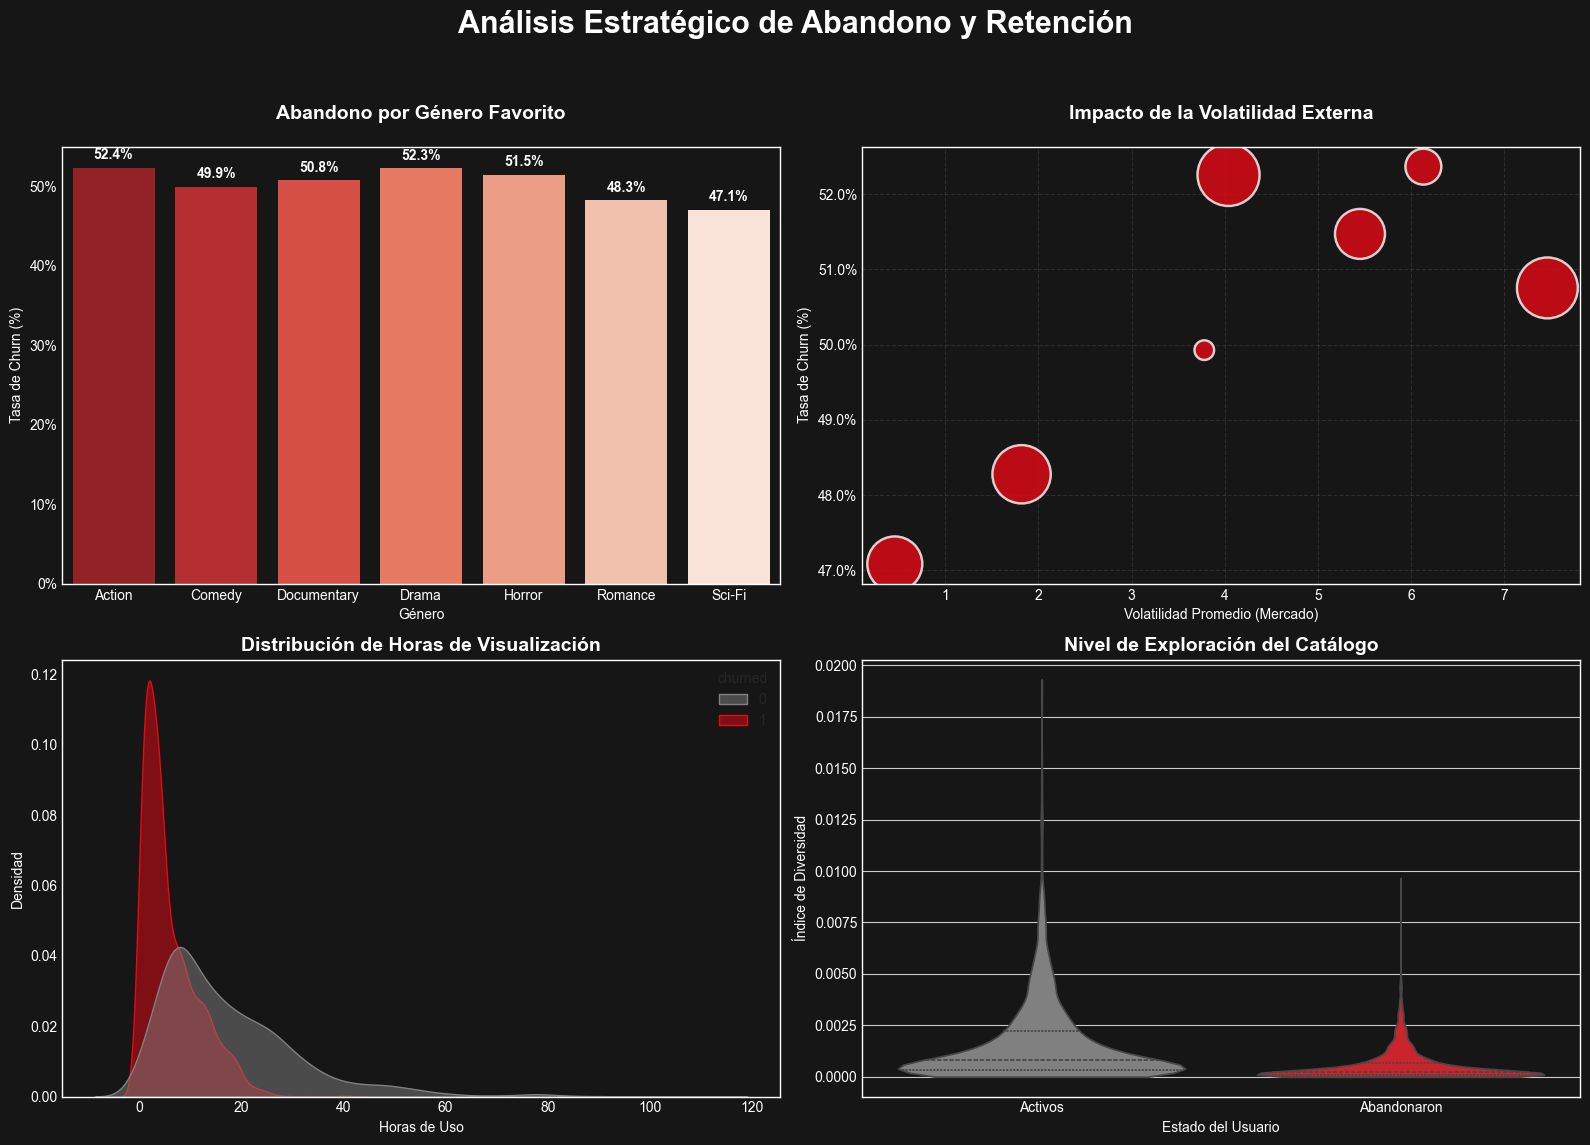

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

# Configuración de estilo y constantes
plt.style.use("seaborn-v0_8-whitegrid")
NETFLIX_RED = "#E50914"
BG_DARK = "#171616"
WHITE = "#FFFFFF"

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.patch.set_facecolor(BG_DARK)

fig.suptitle(
    "Análisis Estratégico de Abandono y Retención",
    fontsize=22, color=WHITE, weight="bold", y=0.98
)

# Tasa de Abandono por Género (Barras con % y etiquetas)
axes[0, 0].set_facecolor(BG_DARK)
merged_data = genre_context.merge(churn_by_genre, on="favorite_genre")

bars = sns.barplot(
    ax=axes[0, 0],
    data=merged_data,
    x="favorite_genre", y="churn_rate",
    palette="Reds_r"
)

# Formatear eje Y como porcentaje para que sea más claro
axes[0, 0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# Etiquetas de porcentaje sobre cada barra
for p in bars.patches:
    bars.annotate(f'{p.get_height()*100:.1f}%', 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 9), 
                   textcoords = 'offset points',
                   color=WHITE, weight='bold')

axes[0, 0].set_title("Abandono por Género Favorito", color=WHITE, weight="bold", pad=20)
axes[0, 0].set_xlabel("Género", color=WHITE)
axes[0, 0].set_ylabel("Tasa de Churn (%)", color=WHITE)
axes[0, 0].grid(False)

# Volatilidad vs Abandono (Scatter con % en Y)
axes[0, 1].set_facecolor(BG_DARK)
sns.scatterplot(
    ax=axes[0, 1],
    data=merged_data,
    x="avg_volatility", y="churn_rate",
    size="users", sizes=(200, 2000), 
    color=NETFLIX_RED, alpha=0.8, legend=False
)
axes[0, 1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[0, 1].set_title("Impacto de la Volatilidad Externa", color=WHITE, weight="bold", pad=20)
axes[0, 1].set_xlabel("Volatilidad Promedio (Mercado)", color=WHITE)
axes[0, 1].set_ylabel("Tasa de Churn (%)", color=WHITE)
axes[0, 1].grid(True, color=WHITE, alpha=0.1, linestyle="--")

#Intensidad de Uso (KDE)
axes[1, 0].set_facecolor(BG_DARK)
sns.kdeplot(
    ax=axes[1, 0], data=df_enriched, x="watch_hours", hue="churned", 
    fill=True, common_norm=False, palette=["#808080", NETFLIX_RED], alpha=0.5
)
axes[1, 0].set_title("Distribución de Horas de Visualización", color=WHITE, weight="bold")
axes[1, 0].set_xlabel("Horas de Uso", color=WHITE)
axes[1, 0].set_ylabel("Densidad", color=WHITE)
axes[1, 0].grid(False)

# Violín: Exploración
axes[1, 1].set_facecolor(BG_DARK)
sns.violinplot(
    ax=axes[1, 1], data=df_enriched, x="churned", y="content_saturation_index",
    palette=["#808080", NETFLIX_RED], bw_method=0.2, inner="quartile", cut=0
)
axes[1, 1].set_title("Nivel de Exploración del Catálogo", color=WHITE, weight="bold")
axes[1, 1].set_xticklabels(["Activos", "Abandonaron"], color=WHITE)
axes[1, 1].set_xlabel("Estado del Usuario", color=WHITE)
axes[1, 1].set_ylabel("Índice de Diversidad", color=WHITE)

# Bordes y ticks para todos
for ax in axes.flat:
    ax.tick_params(colors=WHITE)
    for spine in ax.spines.values():
        spine.set_color(WHITE)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## 7. Metadata

In [ ]:
print("DIMENSIONES FINALES:")
print(df_enriched.shape)

print("\nCOLUMNAS FINALES:")
print(list(df_enriched.columns))

print("\nTIPOS DE DATOS:")
print(df_enriched.dtypes)

print("\nVARIABLES NUMÉRICAS:")
num_cols = df_enriched.select_dtypes(include=['int64','float64']).columns
print(list(num_cols))

print("\nVARIABLES CATEGÓRICAS:")
cat_cols = df_enriched.select_dtypes(include=['object']).columns
print(list(cat_cols))

print("\nVALORES NULOS:")
print(df_enriched.isnull().sum())


DIMENSIONES FINALES:
(5000, 20)

COLUMNAS FINALES:
['customer_id', 'age', 'gender', 'subscription_type', 'watch_hours', 'last_login_days', 'region', 'device', 'monthly_fee', 'churned', 'payment_method', 'number_of_profiles', 'avg_watch_time_per_day', 'favorite_genre', 'wikidata_total_titles', 'genre_volatility', 'genre_trend_slope', 'content_offer_percentile', 'content_saturation_index', 'relative_engagement']

TIPOS DE DATOS:
customer_id                  object
age                           int64
gender                       object
subscription_type            object
watch_hours                 float64
last_login_days               int64
region                       object
device                       object
monthly_fee                 float64
churned                       int64
payment_method               object
number_of_profiles            int64
avg_watch_time_per_day      float64
favorite_genre               object
wikidata_total_titles         int64
genre_volatility            f

## 8. Insights – Engagement y Abandono

### Horas de visualización
Los usuarios que no abandonan presentan una mediana de horas vistas significativamente mayor y mayor dispersión.  
Quienes abandonan concentran su consumo en niveles bajos.

**Insight:** El churn está asociado a bajo engagement sostenido.

### Saturación de contenido
Los usuarios activos muestran mayor índice de saturación y mayor exploración del catálogo.  
Los usuarios que abandonan consumen poco antes de irse.

**Insight:** La interacción intensiva con el catálogo actúa como factor de retención, no de fatiga.

### Género y abandono
Existen diferencias moderadas por género. Drama, Horror y Action presentan tasas levemente más altas, mientras que Romance y Sci-Fi muestran menor churn.

**Insight:** El tipo de contenido influye, pero no determina por sí solo el abandono.

### Volatilidad externa
Géneros con mayor volatilidad en búsquedas (Google Trends) tienden a mostrar churn ligeramente más alto.

**Insight:** El interés cultural inestable se asocia a menor lealtad.

### 9. Conclusión general
Los resultados indican que el abandono de usuarios está principalmente vinculado a **niveles bajos de engagement**, medidos tanto en horas de visualización como en aprovechamiento del catálogo.  
Los factores externos y el tipo de contenido influyen, pero de forma secundaria frente al comportamiento de consumo dentro de la plataforma.

**Conclusión clave:**  
La retención depende más de **cómo y cuánto consume el usuario**, que de qué contenido específico o tendencias externas lo atraen inicialmente.
